## EigenSig: Eigenspace-Based Gap Filling and Applications

PyGap implements the **EigenSig** methodology, an eigenspace-based approach for filling data gaps, separating signals, and analyzing structural patterns in spatio-temporal datasets. Unlike harmonic approaches that rely on predefined Fourier components, EigenSig is entirely **data-driven**, extracting dominant structures directly from the observations. This makes it particularly suitable for geophysical, environmental, and climate datasets that contain irregular sampling, long data gaps, transient events, and non-stationary behavior.

### Purpose

The primary goal of EigenSig is to reconstruct missing observations while preserving the intrinsic structures of the original signal. In addition to gap filling, it supports signal separation, anomaly detection, noise reduction, and energy-structure analysis. By exploiting auto-correlations in the data, EigenSig can recover both global trends and localized variations without imposing a stationarity assumption. 

### Method and Mathematical Foundation

The method begins by partitioning a time series into epochs and reshaping it into an embedded matrix Y. Principal Component Analysis (PCA) or Singular Value Decomposition (SVD) is then applied:

  $Y = U \Sigma V^T$

where U and V are orthogonal eigenvector matrices and Σ contains singular values. The decomposition separates the signal into a set of ranked eigenspace components, revealing how energy is distributed among dominant structures. Because most signal energy is typically concentrated in a few leading modes, the dataset can be represented in a low-dimensional subspace while preserving its essential characteristics.

For gap filling, EigenSig reconstructs the signal by interpolating trajectories in the reduced eigenspace rather than directly fitting the original observations. Missing values are estimated through the reconstructed eigenspace coordinates:
The decomposition can also be expressed as:

   $Y_x = U_x (\Sigma V^T)$


This approach exploits intrinsic structure within the data and avoids explicit modeling of high-frequency behavior.

A key advantage of EigenSig is its ability to preserve local variability, sharp gradients, and transient features, which are often smoothed or distorted by conventional interpolation methods. It also removes the requirement for a global stationarity assumption and is computationally efficient because it relies on low-rank matrix representations rather than repeated global optimizations.

In summary, EigenPy provides a robust framework for reconstruction, anomaly separation, and structural analysis of incomplete spatio-temporal datasets. Its eigenspace formulation enables accurate gap filling while maintaining both global trends and local signal characteristics, making it especially suitable for non-stationary geophysical observations the original signal domain. 

### Key Features

- Data-driven eigenspace representation.
- No global stationarity assumption.
- Preserves local variability and sharp transitions.
- Handles wide and continuous data gaps.
- Efficient low-rank reconstruction using SVD.
- Supports anomaly separation and noise filtering.
- Provides energy-structure analysis through singular spectrum analysis (SSA)

### 5 steps (indicated in the demo codes) 
- import pyGap package
- prepare .csv data, import it into Pandas's dataframe, the DateTime column follow standard Python format,see examples with
- construct GapFilling object 
- fill gaps using gp.predict() with 
- dump, chart results and analysis
 

### Discussion

Unlike traditional interpolation techniques such as splines or kriging, or advanced least square harmonic analysis (LSHE), EigenSig does not rely on fixed functional forms or stationary covariance assumptions. Instead, it learns dominant structures directly from the data, allowing it to capture both long-term behavior and local transient features. Because reconstruction occurs within a low-dimensional eigenspace, the method is computationally efficient while maintaining high fidelity to the original signal. Comparative studies show that EigenSig generally preserves localized features better than globally fitted models and performs particularly well for non-stationary geophysical observations. 

### Conclusion

EigenPy provides an effective eigenspace framework for gap filling, signal reconstruction, anomaly separation, and structural analysis. By combining matrix embedding, PCA/SVD decomposition, and eigenspace interpolation, it reconstructs missing observations while preserving the natural variability of the data. The method is especially valuable for complex non-stationary spatio-temporal datasets where maintaining local signal characteristics is critical.

### Referrence

Li, Qingmou and Liu, Wenjun, 2026. Gap Filling and Anomaly Separation Using Inverse Principal Components Analysis, Pure Appl. Geophys., https://doi.org/10.1007/s00024-026-04053-5



## Following is a full Python example 

In [1]:
import numpy as np
import time

from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

#step 1: import the PyGap
from PyGap import dataSamples as ds
from PyGap import EigenSig
from PyGap import LSHE
from PyGap import charts

#step 2: load asc data (.csv) into Pandas' DataFrame, display the first 5 rows 
df_data = ds.load_Ott_Hour()      
chanell = 'Y'          # select the column 
df = df_data.loc['2018-05-01':'2018-06-01'] 

rows = df[chanell].values.shape[0] // 24  #24 is the epoch: 1 day records have 24 samples for 1-hour data
df   = df.iloc[:rows*24].copy()           #extract exactly the series of full periods
print(df.head(5))

... Loaded PyGap ...
                            X        Y         Z     F
DateTime                                              
2018-05-01 00:00:00  17898.96 -4311.56  50974.18 -0.31
2018-05-01 01:00:00  17900.12 -4311.87  50973.93 -0.33
2018-05-01 02:00:00  17899.36 -4312.20  50973.62 -0.36
2018-05-01 03:00:00  17897.82 -4312.08  50973.60 -0.28
2018-05-01 04:00:00  17898.49 -4311.14  50973.67 -0.20


                            X        Y         Z     F  SynthticGaps  \
DateTime                                                               
2018-05-01 00:00:00  17898.96 -4311.56  50974.18 -0.31      -4311.56   
2018-05-01 01:00:00  17900.12 -4311.87  50973.93 -0.33      -4311.87   
2018-05-01 02:00:00  17899.36 -4312.20  50973.62 -0.36      -4312.20   
2018-05-01 03:00:00  17897.82 -4312.08  50973.60 -0.28      -4312.08   
2018-05-01 04:00:00  17898.49 -4311.14  50973.67 -0.20      -4311.14   

                     EigenSigFilled  EigenSigResiduals  
DateTime                                                
2018-05-01 00:00:00        -4311.56      -1.455192e-11  
2018-05-01 01:00:00        -4311.87      -1.273293e-11  
2018-05-01 02:00:00        -4312.20      -9.094947e-12  
2018-05-01 03:00:00        -4312.08      -2.728484e-12  
2018-05-01 04:00:00        -4311.14      -9.094947e-12  


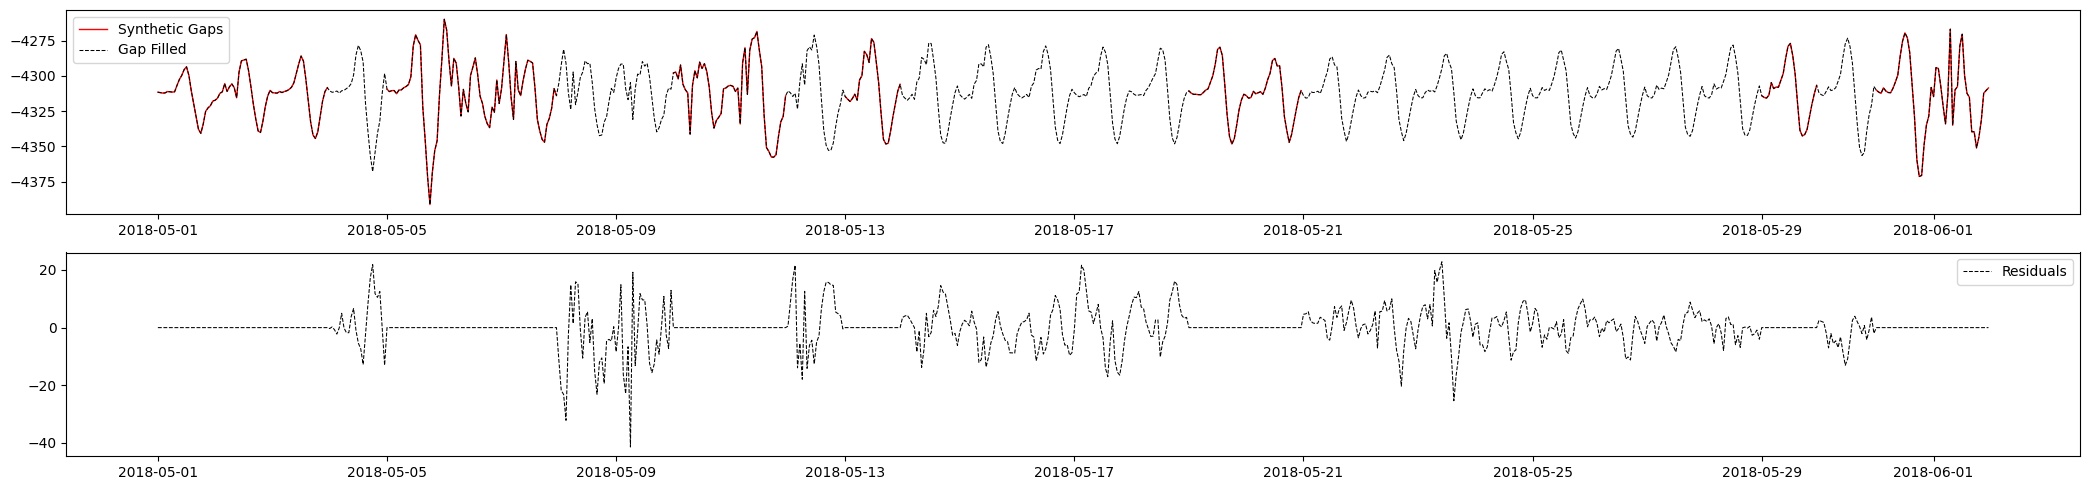

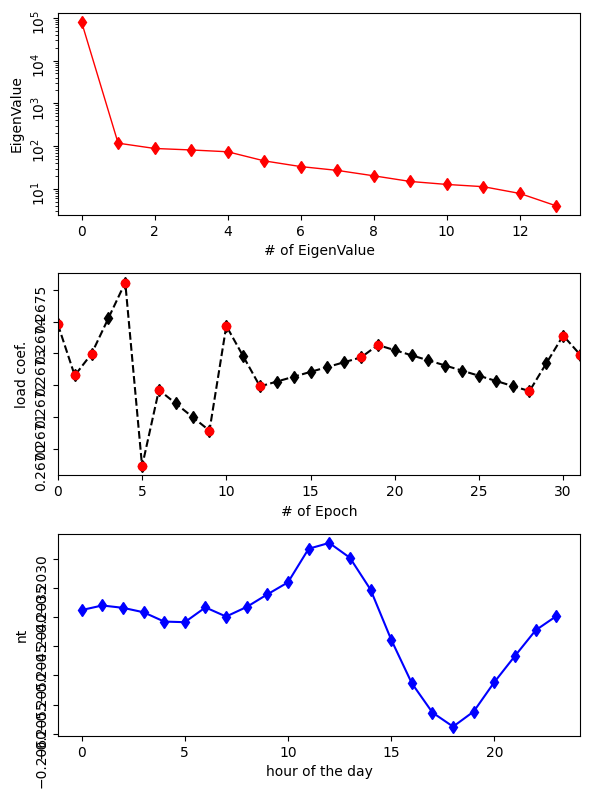

In [5]:
#step 3: prepare synthetic data gaps 
allDis=np.array([x for x in range(rows)], dtype=float) #allDis the number of rows in the continous (full) time series without data gaps
allTS =df[chanell].values
T = np.array([x for x in range(allTS.shape[0])])
#synthetic gaps
delList=[3,7,8,11,13, 14,15,16,17,20,21,22,23,24,25,26,27,29]  
TS4plt = allTS.copy().reshape(rows,-1)     
    
for dl in delList:
    TS4plt[dl,:] = np.nan
df['SynthticGaps'] = TS4plt.flatten()
dis = np.delete(allDis,delList, axis=0)     #sequence of rows in the folder time series with data gaps  

TS  = np.delete(allTS.reshape(rows,-1),delList, axis=0).flatten() #TS is 1D time series with gaps removed
T_del = np.delete(T.reshape(rows,-1),delList, axis=0).flatten()  
"""
#dump to show favorite data for EigenSig as shown in eigenData_example.csv 

with open('eigenData_example.csv', 'w') as hfile:
    hfile.write('epochSequence, y0,')
    for r in range(1,23):
        hfile.write(f'y{r},')
    hfile.write('y23\n')
    
    for ep in range(dis.shape[0]):        #dump epoch by epoch
        hfile.write(f'{dis[ep]},')
        for m in range(23):   #df['SynthticGaps'].values.shape[0]/24):  #how many epochs
            hfile.write(f'{TS[ep*24+m]:.1f},')
        hfile.write(f'{TS[ep*24+23]:.1f}\n')    #the last one       
"""

#step 4: construct gap filling object, fit model using data with gaps. then filling (predict) gaps in the data. 
gf = EigenSig.GapFilling()
      
gf.fit(dis,TS)

filled = gf.predict(allDis, inter1D='slinear', filtStr='0:')  
'''
inter1D can be one of following (supported from SciPy):
            'slinear', 
            'nearest'
            'nearest-up'
            'zero'            
            'quadratic'
            'cubic'
            'previous'
            'next' 
filtStr:
     ='0:'
'''
df['EigenSigFilled'] = filled                                 # save gap filled results into the dataframe
df['EigenSigResiduals'] = df[chanell] - df['EigenSigFilled']  #save residuals into the dataframe   

# step 5: display gap filled results and plot SSA, ...,...
print(df.head(5))
charts.plotEigenSigFilled(df)  #plot curves
charts.chartEigenSig(gf)       #plot energy structure, loadings and basis of eigenspace